# Telecommunications Project

### Introduction

The virtual telephony service CallMeMaybe aims to improve the monitoring of operator performance by identifying those with low efficiency levels. In this context, an operator is considered inefficient if they have a high proportion of missed incoming calls, long waiting times, and, in the case of making outgoing calls, a low volume of such calls.

The objective of this project is to analyze the provided data on the use of the telephony system in order to identify behavioral patterns associated with inefficient operators. To achieve this, an exploratory data analysis (EDA) will be conducted, relevant metrics such as missed call rate and waiting time will be constructed, and an evaluation model will be developed to classify operators based on their performance level.

Additionally, statistical hypothesis tests will be applied to validate whether the observed differences between efficient and inefficient operators are statistically significant, supporting the findings with quantitative evidence.

This analysis will not only help identify low-performing operators but also provide valuable insights for decision-making aimed at improving the operational efficiency of the service.

### Load the Libraries and Datasets to Be Used

In [145]:
# Load the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy import stats

In [146]:
# Load the datasets

clients = pd.read_csv('telecom_clients.csv')

calls = pd.read_csv('telecom_dataset_new.csv')

## Data Exploration

In [147]:
# Review the first rows of the dataset and its general information

print(clients.head(),
      clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16 None


In [148]:
# Display the first rows of the dataset and a summary of its structure (data types and non-null values)
print(calls.head(),
      calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     

In [149]:
# Check for missing values in the dataset
calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [150]:
# Check for missing values in the dataset
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [151]:
# Display descriptive statistics of numerical variables (mean, standard deviation, min and max values)
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [152]:
# Count the number of unique operators and users in the dataset
calls['operator_id'].nunique()
calls['user_id'].nunique()

307

In [153]:
# Sum the total number of calls grouped by direction (incoming vs outgoing)
calls.groupby('direction')['calls_count'].sum()

direction
in     216863
out    669892
Name: calls_count, dtype: int64

In [154]:
# Count the number of duplicate records in the dataset
calls.duplicated().sum()

np.int64(4900)

### Initial Observations

- In the **calls** dataset, the data type of the 'date' column is object; it should be converted to 'datetime'.  
- In the **clients** dataset, the data type of the 'date_start' column is object; it will be converted to 'datetime'.  
- Missing values are observed in the 'internal' and 'operator_id' columns of the **calls** dataset.

### Data Cleaning

In [155]:
# Convert dates

# Convert the 'date' column in the calls dataset to datetime
calls['date'] = pd.to_datetime(calls['date'])

# Convert the 'date_start' column in the clients dataset to datetime
clients['date_start'] = pd.to_datetime(clients['date_start'])

In [156]:
# Remove missing values from the calls dataset

calls = calls.dropna(subset=['operator_id', 'internal'])

# Verify that missing values have been removed from the calls dataset
calls.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

### Changes Made

- The conversion of the 'date_start' column in the **clients** dataset to datetime was corrected.  
- Missing values in the 'internal' and 'operator_id' columns of the **calls** dataset were removed, since an operator cannot be analyzed if the data is null.

## Inefficient Operators

Now that our data is clean, we can identify which operators are inefficient by considering the number of missed calls (internal and external) and the waiting time for incoming calls.

In [157]:
# Descriptive statistics of the calls dataset
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,45670.000000,45670.000000,45670.000000,45670.000000,45670.000000
mean,167302.011408,916529.298796,16.925203,1010.934399,1323.697000
std,600.836406,21258.404689,59.081220,4017.101865,4735.336635
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000
50%,167175.000000,913938.000000,4.000000,107.000000,291.000000
75%,167827.000000,937708.000000,14.000000,774.000000,1112.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


The descriptive statistics show high variability in the number and duration of calls, evidenced by the large difference between minimum and maximum values. Additionally, the median number of calls is relatively low compared to the mean, suggesting the presence of outliers that increase the average.

### Internal vs External Calls

In [158]:
# Check the number of internal calls (between staff) vs external calls (with customers)
calls['internal'].value_counts()

internal
False    39861
True      5809
Name: count, dtype: int64

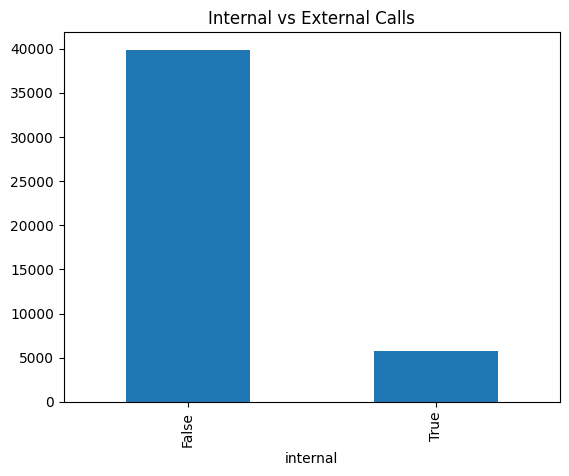

In [159]:
# Distribution of internal vs external calls
calls['internal'].value_counts().plot(
    kind='bar', title='Internal vs External Calls')
plt.show()

### Analysis of Internal vs External Calls

Most calls are external (approximately 39,861), while internal calls represent a much smaller proportion (around 5,809). This indicates that the system is primarily used for communication with customers, which is consistent with the nature of the service.

Although less frequent, internal calls may be relevant for coordination between operators, but they do not represent the main operational workload.

### Incoming vs Outgoing Calls

In [160]:
# Incoming vs outgoing calls
calls['direction'].value_counts()

direction
out    31717
in     13953
Name: count, dtype: int64

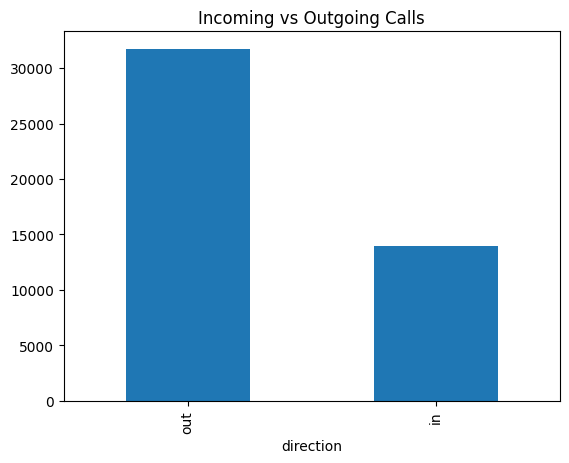

In [161]:
# Distribution of incoming vs outgoing calls
calls['direction'].value_counts().plot(
    kind='bar', title='Incoming vs Outgoing Calls')
plt.show()

### Analysis of Incoming vs Outgoing Calls

The distribution of calls shows that most are outgoing calls (31,717), while incoming calls represent a smaller proportion (13,953). This indicates that operators not only handle calls but also make a considerable number of calls to customers.

This behavior is relevant for efficiency analysis, as a low number of outgoing calls per operator could be an indicator of poor performance in cases where proactive activity is expected. Therefore, this variable will be considered in the evaluation of inefficient operators.

### Call Metrics

We will create and analyze call metrics, which will be useful for identifying inefficient operators.

In [162]:
# Waiting time
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

In [163]:
# Crear wait_time
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

# Agrupar
operator_stats = calls.groupby('operator_id').agg({
    'calls_count': 'sum',
    'is_missed_call': 'mean',
    'call_duration': 'mean',
    'wait_time': 'mean',
}).reset_index()

# Renombrar
operator_stats = operator_stats.rename(columns={
    'is_missed_call': 'missed_rate'
})

# Llamadas salientes
outgoing = calls[calls['direction'] == 'out']

outgoing_calls = outgoing.groupby(
    'operator_id')['calls_count'].sum().reset_index()
outgoing_calls = outgoing_calls.rename(
    columns={'calls_count': 'outgoing_calls'})

# Merge
operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')

# Fill NA
operator_stats['outgoing_calls'] = operator_stats['outgoing_calls'].fillna(0)

### Criteria to Identify Inefficient Operators

- High number of missed calls  
- High waiting time  
- Low number of outgoing calls  

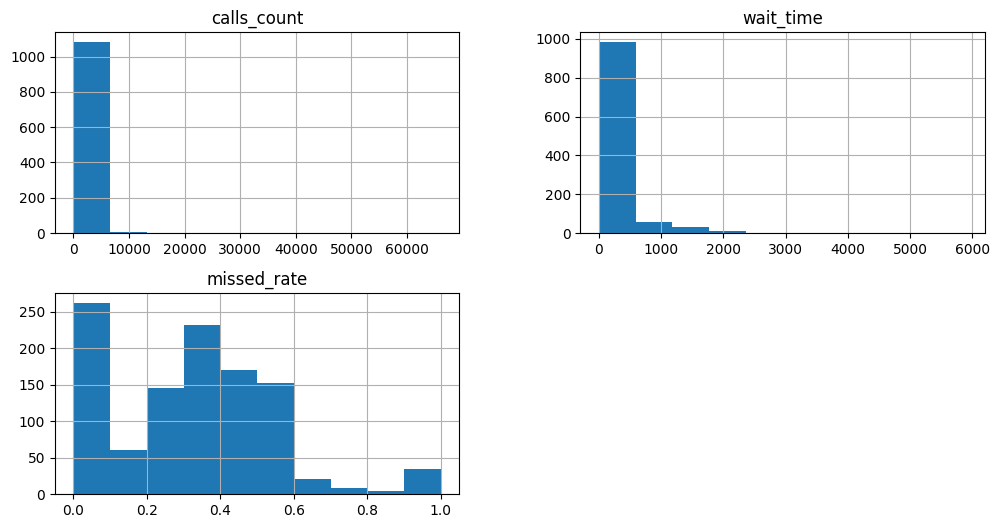

In [164]:
# Visualize the distribution of key metrics per operator (calls, waiting time, and missed call rate)
operator_stats[['calls_count', 'wait_time',
                'missed_rate']].hist(figsize=(12, 6))
plt.show()

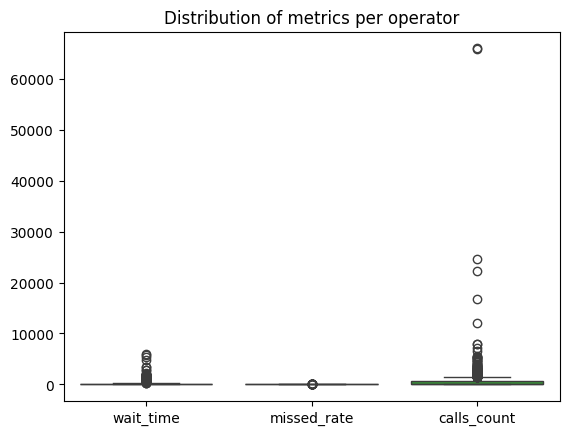

In [165]:
# Display boxplots of key metrics to identify dispersion and potential outliers per operator
sns.boxplot(data=operator_stats[['wait_time', 'missed_rate', 'calls_count']])
plt.title('Distribution of metrics per operator')
plt.show()

# Creation of Plots for Each Metric by Operator

In [166]:
# Filter outgoing calls and sum total per operator
outgoing_calls = calls[calls['direction'] == 'out'].groupby('operator_id')[
    'calls_count'].sum()

# Merge outgoing calls with operator metrics dataset
operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')

# Create outgoing_calls column and replace missing values with 0
operator_stats['outgoing_calls'] = operator_stats['calls_count_y'].fillna(0)

# Drop duplicate column generated by the merge
operator_stats.drop(columns=['calls_count_y'], inplace=True)

# Check dataset columns
print(operator_stats.columns)

# Rename original total calls column
operator_stats.rename(columns={
    'calls_count_x': 'calls_count'
}, inplace=True)

Index(['operator_id', 'calls_count_x', 'missed_rate', 'call_duration',
       'wait_time', 'outgoing_calls'],
      dtype='object')


In [167]:
# Create an interactive chart that allows visualization of different metrics per operator using a dropdown menu

fig = go.Figure()

metrics = {
    'Total Calls': 'calls_count',
    'Missed Rate': 'missed_rate',
    'Wait Time': 'wait_time',
    'Call Duration': 'call_duration'
}

# Create traces
for i, (label, col) in enumerate(metrics.items()):
    fig.add_trace(
        go.Scatter(
            x=operator_stats['operator_id'],
            y=operator_stats[col],
            mode='markers',
            name=label,
            visible=(i == 0)  # only the first one visible
        )
    )

# Create dropdown
buttons = []
for i, (label, col) in enumerate(metrics.items()):
    visible = [False] * len(metrics)
    visible[i] = True

    buttons.append(
        dict(
            label=label,
            method='update',
            args=[
                {'visible': visible},
                {
                    'title': f'{label} per operator',
                    'yaxis': {'title': label}
                }
            ]
        )
    )

# Layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.1,
            y=1.15
        )
    ],
    title='Total Calls per operator',
    xaxis_title='Operator ID',
    yaxis_title='Metric',
    height=600
)

fig.show()

## Analysis of Metrics by Operator

The distributions of the metrics show high variability among operators, suggesting important differences in their performance.

In the case of `calls_count`, there is a strong right skew, with some operators handling a significantly higher volume of calls than others, indicating the presence of outliers. This may reflect an uneven distribution of workload.

For `wait_time`, most operators have low waiting times, but there are some cases with significantly high values, which may indicate inefficiencies in call handling.

The `missed_rate` metric shows a more concentrated distribution, although some operators have high missed call rates, which is a critical factor in performance evaluation.

The boxplot confirms the presence of multiple outliers across all metrics, especially in the number of calls and waiting time. These extreme values are particularly relevant, as they may correspond to highly efficient operators or, conversely, inefficient operators that require attention.

Overall, these results support the defined criteria for identifying inefficient operators, as they highlight the existence of operators with high waiting times, high missed call rates, and atypical call volume behavior.

## Percentile Analysis

In this section, the 90th, 95th, and 99th percentiles are calculated for key metrics (`calls_count`, `missed_rate`, and `wait_time`) in order to identify extreme values within the data distribution.

Percentiles help us understand the behavior of the highest values, which is especially useful for detecting operators with atypical performance, whether due to handling an excessive volume of calls, having high waiting times, or exhibiting a high missed call rate.

In [168]:
# Calculate the 90th, 95th, and 99th percentiles of calls per operator to identify high values (outliers)
print(np.percentile(operator_stats['calls_count'], [90, 95, 99]))

[1790.5  2659.75 5456.8 ]


In [169]:
# Calculate the 90th, 95th, and 99th percentiles of the missed call rate to detect high values
print(np.percentile(operator_stats['missed_rate'], [90, 95, 99]))

[0.54033264 0.66666667 1.        ]


In [170]:
# Calculate the 90th, 95th, and 99th percentiles of waiting time to identify extreme values
print(np.percentile(operator_stats['wait_time'], [90, 95, 99]))

[ 546.65147059 1127.36605405 1935.69478006]


## Interpretation of Results

The results show that, at the 90th percentile, some operators already exhibit considerably high values compared to the rest, especially in the number of calls and waiting time.

From the 95th percentile, and more clearly at the 99th percentile, extreme values are observed, confirming the presence of outliers in the analyzed metrics. For example, some operators have significantly high waiting times and missed call rates close to the maximum.

These findings are important because they help establish thresholds to identify potentially inefficient operators. In particular, those who fall into the highest percentiles of `wait_time` and `missed_rate`, or the lowest levels of activity (`calls_count`), can be considered candidates for performance evaluation.

## Inefficiency Score Construction

In this section, a composite indicator (score) was built to evaluate the efficiency of each operator. To achieve this, Min-Max normalization was applied to key variables (`missed_rate`, `wait_time`, `calls_count`, and `outgoing_calls`) in order to bring them to a common scale between 0 and 1.

Subsequently, weights were assigned to each metric according to their importance in identifying inefficiency: greater weight was given to the missed call rate and waiting time, and lower weight to call volume and outgoing calls (considering that lower values in these indicate lower performance).

Finally, operators were identified as inefficient if they fall within the 95th percentile of the score, and their behavior was visualized using a scatter plot.

In [171]:
# Normalize the values of each metric to a 0–1 range
def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-6)


# Calculate an inefficiency score giving higher weight to missed_rate and wait_time
operator_stats['score'] = (
    # Higher weight: missed calls
    minmax(operator_stats['missed_rate']) * 0.5 +
    # High weight: waiting time
    minmax(operator_stats['wait_time']) * 0.4 +
    # Low weight: call volume
    (1 - minmax(operator_stats['calls_count'])) * 0.05 +
    (1 - minmax(operator_stats['outgoing_calls'])) *
    0.05  # Low weight: outgoing calls
)

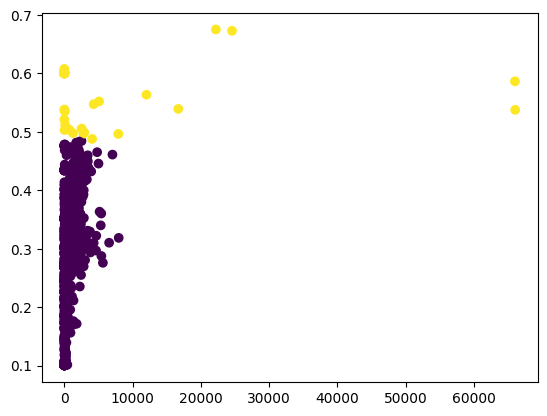

In [172]:
# Identify the top 5% most inefficient operators and highlight them in the plot
colors = operator_stats['score'] > operator_stats['score'].quantile(0.95)

plt.scatter(
    operator_stats['calls_count'],
    operator_stats['score'],
    c=colors
)

plt.show()

## Inefficiency Score Analysis

The chart shows the relationship between the number of calls (`calls_count`) and the calculated inefficiency score for each operator. It can be observed that most operators are concentrated at lower call volumes, with moderate inefficiency values.

The highlighted operators (95th percentile of the score) represent the most inefficient group. These tend to have high score values, indicating a combination of high waiting times and high missed call rates—factors that carry greater weight in the model.

Additionally, some operators are identified with a high call volume but relatively low inefficiency levels, suggesting better operational performance.

Overall, the score clearly distinguishes low-performing operators, validating the defined criteria and facilitating their identification for further analysis or intervention.

In [173]:
# Display operators with the worst inefficiency score
operator_stats.sort_values(by='score', ascending=True).head()

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls,score
959,952954.0,3,0.0,7.666667,1.000000,0.0,0.100066
911,948282.0,1,0.0,60.000000,1.000000,0.0,0.100068
961,952982.0,9,0.0,56.571429,1.142857,0.0,0.100071
1027,960666.0,2,0.0,125.000000,3.000000,2.0,0.100201
871,946020.0,1,0.0,5.000000,3.000000,0.0,0.100203


## Hypothesis Testing

### Comparing Efficient vs Inefficient Operators

Hypotheses:
- H0 (null):
There is no difference in waiting time between efficient and inefficient operators  
- H1 (alternative):
Inefficient operators have higher waiting time

In [174]:
# Define inefficient operators (top 5%)
threshold = operator_stats['score'].quantile(0.95)

# Split groups
inefficient = operator_stats[operator_stats['score'] >= threshold]['wait_time']
efficient = operator_stats[operator_stats['score'] < threshold]['wait_time']

# T-test
t_stat, p_value = stats.ttest_ind(inefficient, efficient, equal_var=False)

print("p-value:", p_value)

p-value: 0.0016346867111482013


In [175]:
# Evaluate the p-value to decide whether to reject the null hypothesis and determine if there is a significant difference
if p_value < 0.05:
    print("Reject H0")
    print("There is a significant difference")
    print("Inefficient operators have higher waiting time")
else:
    print("There is not enough evidence to reject H0")

Reject H0
There is a significant difference
Inefficient operators have higher waiting time


## Hypothesis 2

### Relationship Between Missed Calls and Waiting Time

Hypotheses:
- H0: There is no relationship between missed_rate and wait_time  
- H1: There is a relationship

In [176]:
# Calculate the Pearson correlation between missed call rate and waiting time
corr, p_value = stats.pearsonr(
    operator_stats['missed_rate'], operator_stats['wait_time'])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.23698748227551483
p-value: 2.093170839392635e-15


In [177]:
# Interpret the p-value and correlation to determine if there is a significant relationship between the variables
if p_value < 0.05:
    print("There is a statistically significant relationship")

    if corr > 0:
        print(
            "The higher the waiting time, the higher the number of missed calls")

    print("This supports the inefficiency model")
else:
    print("No statistically significant relationship was found")

There is a statistically significant relationship
The higher the waiting time, the higher the number of missed calls
This supports the inefficiency model


## Hypothesis 3

### Calls Made vs Efficiency

- H0: The number of calls does not affect efficiency.  
- H1: Fewer calls = more inefficiency.

In [178]:
# Define threshold (if not already defined)
threshold = operator_stats['score'].quantile(0.95)

# Split inefficient and efficient operators
inefficient_calls = operator_stats[operator_stats['score']
                                   >= threshold]['calls_count']
efficient_calls = operator_stats[operator_stats['score']
                                 < threshold]['calls_count']

# Perform a t-test to compare the number of calls between efficient and inefficient operators
# and determine if the difference is statistically significant (α = 0.05)

# Significance level
alpha = 0.05

# Statistical test
t_stat, p_value = stats.ttest_ind(
    inefficient_calls, efficient_calls, equal_var=False)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}\n")

# Decision
if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in the number of calls")

    # Additional interpretation based on means
    if inefficient_calls.mean() < efficient_calls.mean():
        print("Inefficient operators make fewer calls")
        print("This supports the hypothesis that fewer calls = more inefficiency")
    else:
        print(
            "Unexpected result: inefficient operators do not make fewer calls")
else:
    print("There is not enough evidence to reject H0")

t-statistic: 2.1663590133409913
p-value: 0.03471364337283641

Reject H0
There is a statistically significant difference in the number of calls
Unexpected result: inefficient operators do not make fewer calls


## Final Conclusions

Throughout the analysis, key patterns in the performance of CallMeMaybe operators were identified. Through exploratory data analysis, high variability among operators was observed in metrics such as number of calls, waiting time, and missed call rate, as well as the presence of outliers.

An inefficiency score was constructed based on relevant metrics, prioritizing missed call rate and waiting time, which allowed operators to be classified according to their performance. Based on this indicator, a group of inefficient operators (95th percentile) was identified, characterized by high waiting times, high missed call rates, and low activity levels.

Visual analysis confirmed that the most inefficient operators tend to cluster at lower call volumes, while those with higher activity levels generally show better efficiency.

Additionally, statistical hypothesis testing demonstrated that there are significant differences between efficient and inefficient operators, especially in variables such as waiting time and number of calls, supporting the validity of the proposed model.

Overall, this analysis enables the objective identification of low-performing operators, providing a useful tool for decision-making aimed at improving operational efficiency.

## Recommendations

- Implement training programs focused on reducing waiting time and improving call handling techniques, as these variables showed the greatest impact on inefficiency.  

- Establish key performance indicators (KPIs) such as missed call rate and average waiting time, and monitor them continuously to detect performance deviations among operators.  

- Redistribute workload among operators to avoid low activity levels in some cases, which can negatively impact efficiency and skill development.  

- Implement automated alert systems based on the inefficiency score to identify low-performing operators in real time.  

- Analyze the root causes of missed calls, considering factors such as system overload, long response times, or lack of training.  

- Promote best operational practices based on the analysis of top-performing operators, using them as benchmarks to improve overall team performance.  

- Periodically review and adjust the scoring model weights to ensure they accurately reflect business priorities and current operational conditions.  